In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps

from pathlib import Path
print(np.__version__)

1.26.4


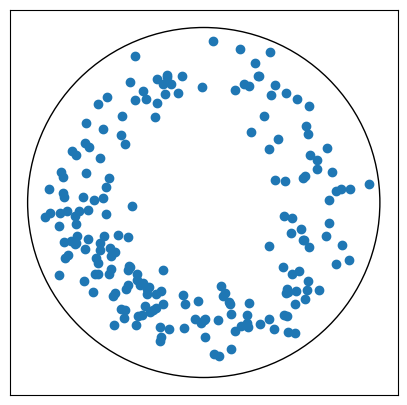

In [9]:
def perturb_points_inside_disc(points, R, noise_scale, seed=None, margin=1e-9):

    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, noise_scale, size=points.shape)
    perturbed_points = points + noise

    radii = np.linalg.norm(perturbed_points, axis=1)
    outside_boundary = radii > R
    if np.any(outside_boundary):
        scale = (R - margin) / radii[outside_boundary]
        perturbed_points[outside_boundary] *= scale[:, None]

    return perturbed_points

radius = 150
original_acc = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/configs/vMB_configs/acceptors.txt")

fig, ax = plt.subplots(figsize=(5,5))
circle = ps.Circle(xy=(0., 0.), radius=radius, fill=None)

ax.scatter(*original_acc.T)
ax.set_xticks([])
ax.set_yticks([])
ax.add_patch(circle)

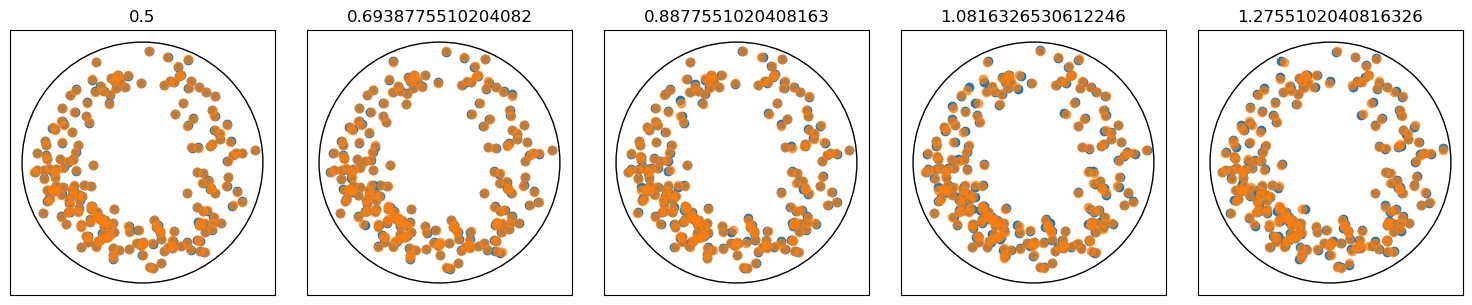

In [10]:
n = 5
noise_levels = np.linspace(0.5, 10, 50)
fig, axs = plt.subplots(ncols=n, figsize=(3 * n, 3))
circle_kwargs = {
    "xy": (0, 0),
    "radius": radius,
    "fill": None
}

save_dir = Path("/home/hd/hd_hd/hd_gy283/kmc_project/configs/perturbated_acceptors/")
save_dir.mkdir(parents=True, exist_ok=True)

perturbed_acc_list = []
for noise in noise_levels:
    perturbed_acc = perturb_points_inside_disc(original_acc, radius, noise, seed=None, margin=1e-6)
    perturbed_acc_list.append(perturbed_acc)
    np.savetxt(f"/home/hd/hd_hd/hd_gy283/kmc_project/configs/perturbated_acceptors/eps={noise}.txt", perturbed_acc, fmt="%6f", delimiter="\t")
    
for i in range(5):

    axs[i].set_aspect("equal")
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].scatter(*perturbed_acc_list[i].T)
    axs[i].scatter(*original_acc.T, alpha=.7)
    axs[i].add_patch(ps.Circle(**circle_kwargs))
    axs[i].set_title(f"{noise_levels[i]}")
plt.tight_layout()